In [ ]:
import pandas as pd

orderbook_url = (
    "https://huggingface.co/datasets/totalorganfailure/lobster-data/"
    "resolve/main/LOBSTER_SampleFile_AAPL_2012-06-21_10/"
    "AAPL_2012-06-21_34200000_57600000_orderbook_10.csv"
)

message_url = (
    "https://huggingface.co/datasets/totalorganfailure/lobster-data/"
    "resolve/main/LOBSTER_SampleFile_AAPL_2012-06-21_10/"
    "AAPL_2012-06-21_34200000_57600000_message_10.csv"
)

orderbook = pd.read_csv(orderbook_url, header=None)
messages = pd.read_csv(message_url, header=None)

print(orderbook.shape)
print(messages.shape)

display(orderbook.head())
display(messages.head())

(400391, 40)
(400391, 6)


,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,5859400,200,5853300,18,5859800,200,5853000,150,5861000,200,...,5845300,300,5876500,1160,5843800,200,5879000,500,5842700,300
1,5859400,200,5853300,18,5859800,200,5853200,18,5861000,200,...,5846500,300,5876500,1160,5845300,300,5879000,500,5843800,200
2,5859400,200,5853300,18,5859800,200,5853200,18,5861000,200,...,5849300,300,5876500,1160,5846500,300,5879000,500,5845300,300
3,5859100,18,5853300,18,5859400,200,5853200,18,5859800,200,...,5849300,300,5873900,100,5846500,300,5876500,1160,5845300,300
4,5859100,18,5853300,18,5859200,18,5853200,18,5859400,200,...,5849300,300,5871000,10,5846500,300,5873900,100,5845300,300


,0,1,2,3,4,5
0,34200.004241,1,16113575,18,5853300,1
1,34200.004261,1,16113584,18,5853200,1
2,34200.004447,1,16113594,18,5853100,1
3,34200.025552,1,16120456,18,5859100,-1
4,34200.025580,1,16120480,18,5859200,-1


In [ ]:
# Name the 40 order-book columns.
orderbook_columns = []

for level in range(1, 11):
    orderbook_columns.extend([
        f"ask_price_{level}",
        f"ask_size_{level}",
        f"bid_price_{level}",
        f"bid_size_{level}",
    ])

orderbook.columns = orderbook_columns

# Name the 6 message columns.
messages.columns = [
    "time",
    "event_type",
    "order_id",
    "size",
    "price",
    "direction",
]

# LOBSTER stores prices multiplied by 10,000.
price_columns = [
    column for column in orderbook.columns
    if "price" in column
]

orderbook[price_columns] = orderbook[price_columns] / 10_000
messages["price"] = messages["price"] / 10_000

display(orderbook.head())
display(messages.head())

orderbook["mid_price"] = (
    orderbook["ask_price_1"]
    + orderbook["bid_price_1"]
) / 2

orderbook["spread"] = (
    orderbook["ask_price_1"]
    - orderbook["bid_price_1"]
)

display(
    orderbook[
        [
            "bid_price_1",
            "ask_price_1",
            "mid_price",
            "spread",
        ]
    ].head()
)

,ask_price_1,ask_size_1,bid_price_1,bid_size_1,ask_price_2,ask_size_2,bid_price_2,bid_size_2,ask_price_3,ask_size_3,...,bid_price_8,bid_size_8,ask_price_9,ask_size_9,bid_price_9,bid_size_9,ask_price_10,ask_size_10,bid_price_10,bid_size_10
0,585.94,200,585.33,18,585.98,200,585.30,150,586.10,200,...,584.53,300,587.65,1160,584.38,200,587.90,500,584.27,300
1,585.94,200,585.33,18,585.98,200,585.32,18,586.10,200,...,584.65,300,587.65,1160,584.53,300,587.90,500,584.38,200
2,585.94,200,585.33,18,585.98,200,585.32,18,586.10,200,...,584.93,300,587.65,1160,584.65,300,587.90,500,584.53,300
3,585.91,18,585.33,18,585.94,200,585.32,18,585.98,200,...,584.93,300,587.39,100,584.65,300,587.65,1160,584.53,300
4,585.91,18,585.33,18,585.92,18,585.32,18,585.94,200,...,584.93,300,587.10,10,584.65,300,587.39,100,584.53,300


,time,event_type,order_id,size,price,direction
0,34200.004241,1,16113575,18,585.33,1
1,34200.004261,1,16113584,18,585.32,1
2,34200.004447,1,16113594,18,585.31,1
3,34200.025552,1,16120456,18,585.91,-1
4,34200.025580,1,16120480,18,585.92,-1


,bid_price_1,ask_price_1,mid_price,spread
0,585.33,585.94,585.635,0.61
1,585.33,585.94,585.635,0.61
2,585.33,585.94,585.635,0.61
3,585.33,585.91,585.620,0.58
4,585.33,585.91,585.620,0.58


In [ ]:
import numpy as np

# Each order-book row matches the message at the same row.
orderbook["time"] = messages["time"]

# Convert seconds after midnight into a readable timestamp.
orderbook["timestamp"] = pd.to_datetime(
    orderbook["time"],
    unit="s",
    origin=pd.Timestamp("2012-06-21")
)

# Add up bid and ask sizes across the first 5 levels.
bid_size_columns = [
    f"bid_size_{level}" for level in range(1, 6)
]

ask_size_columns = [
    f"ask_size_{level}" for level in range(1, 6)
]

orderbook["bid_depth_5"] = (
    orderbook[bid_size_columns].sum(axis=1)
)

orderbook["ask_depth_5"] = (
    orderbook[ask_size_columns].sum(axis=1)
)

total_depth = (
    orderbook["bid_depth_5"]
    + orderbook["ask_depth_5"]
)

orderbook["imbalance_5"] = np.where(
    total_depth == 0,
    0,
    (
        orderbook["bid_depth_5"]
        - orderbook["ask_depth_5"]
    ) / total_depth
)

display(
    orderbook[
        [
            "timestamp",
            "mid_price",
            "spread",
            "bid_depth_5",
            "ask_depth_5",
            "imbalance_5",
        ]
    ].head()
)

,timestamp,mid_price,spread,bid_depth_5,ask_depth_5,imbalance_5
0,2012-06-21 09:30:00.004241228,585.635,0.61,267,950,-0.561216
1,2012-06-21 09:30:00.004260540,585.635,0.61,280,950,-0.544715
2,2012-06-21 09:30:00.004447460,585.635,0.61,209,950,-0.639344
3,2012-06-21 09:30:00.025551796,585.620,0.58,209,918,-0.629104
4,2012-06-21 09:30:00.025579453,585.620,0.58,209,636,-0.505325


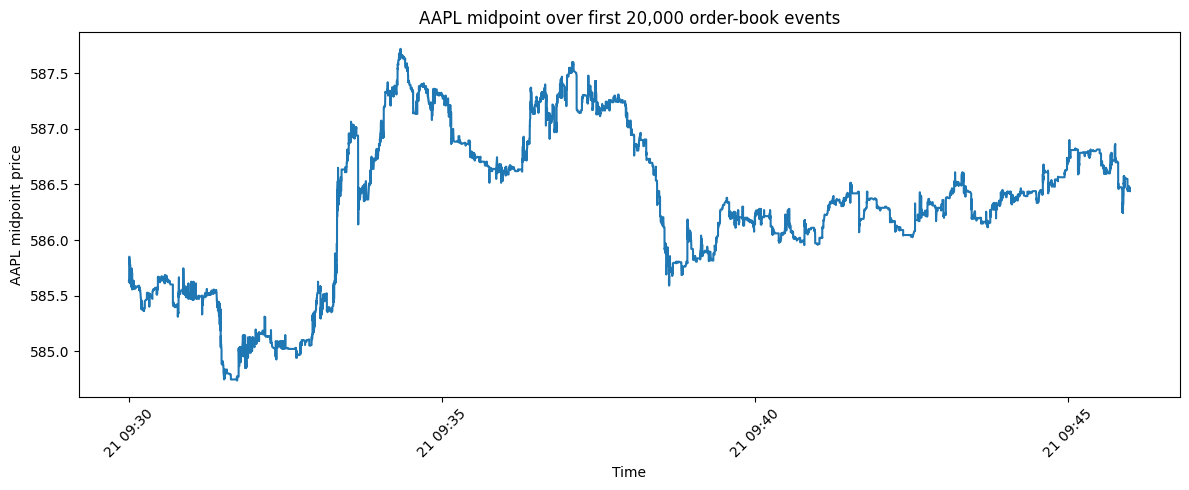

In [ ]:
import matplotlib.pyplot as plt

sample = orderbook.iloc[:20_000]

plt.figure(figsize=(12, 5))
plt.plot(sample["timestamp"], sample["mid_price"])
plt.xlabel("Time")
plt.ylabel("AAPL midpoint price")
plt.title("AAPL midpoint over first 20,000 order-book events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



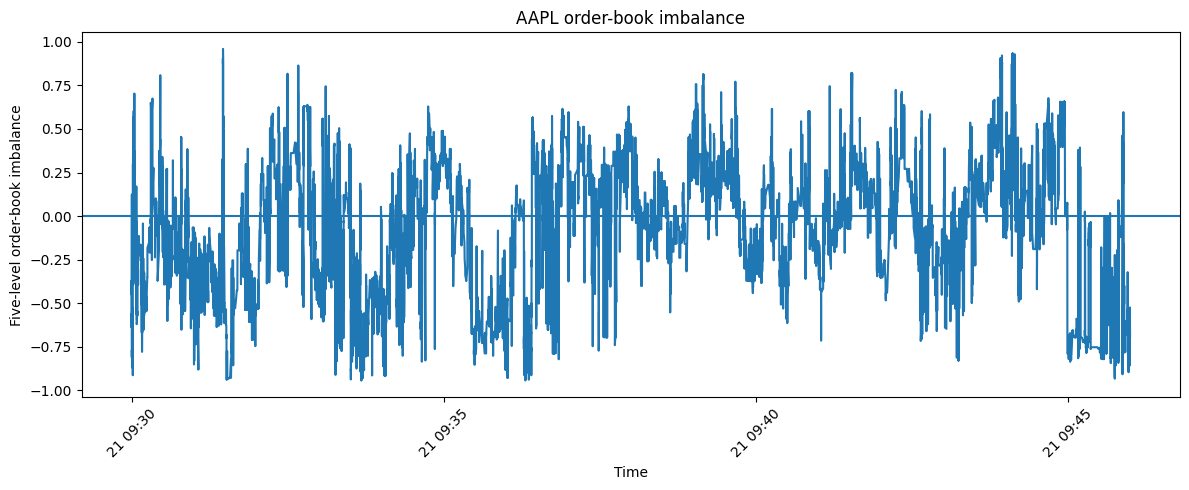

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(sample["timestamp"], sample["imbalance_5"])
plt.axhline(0)
plt.xlabel("Time")
plt.ylabel("Five-level order-book imbalance")
plt.title("AAPL order-book imbalance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Look 20 order-book events into the future.
horizon = 20

# Future midpoint.
orderbook["future_mid_price"] = (
    orderbook["mid_price"].shift(-horizon)
)

# Future price change.
orderbook["future_price_change"] = (
    orderbook["future_mid_price"]
    - orderbook["mid_price"]
)

# Recent midpoint changes.
orderbook["return_1"] = orderbook["mid_price"].pct_change(1)
orderbook["return_5"] = orderbook["mid_price"].pct_change(5)
orderbook["return_20"] = orderbook["mid_price"].pct_change(20)

# Recent volatility.
orderbook["volatility_20"] = (
    orderbook["return_1"]
    .rolling(20)
    .std()
)

# Create the target:
# 1 = up
# 0 = flat
# -1 = down
threshold = 0.01

orderbook["target"] = 0

orderbook.loc[
    orderbook["future_price_change"] > threshold,
    "target"
] = 1

orderbook.loc[
    orderbook["future_price_change"] < -threshold,
    "target"
] = -1

In [ ]:
feature_columns = [
    "spread",
    "bid_depth_5",
    "ask_depth_5",
    "imbalance_5",
    "return_1",
    "return_5",
    "return_20",
    "volatility_20",
]

model_data = orderbook[
    feature_columns + ["target"]
].dropna()

print(model_data.shape)
print(model_data["target"].value_counts())
display(model_data.head())

(400371, 9)
target
 0    175988
-1    114402
 1    109981
Name: count, dtype: int64


,spread,bid_depth_5,ask_depth_5,imbalance_5,return_1,return_5,return_20,volatility_20,target
20,0.01,126,590,-0.648045,0.0,0.000154,0.000171,0.000081,0
21,0.01,126,595,-0.650485,0.0,-0.000162,0.000171,0.000081,0
22,0.01,113,595,-0.680791,0.0,0.000000,0.000171,0.000081,1
23,0.01,113,602,-0.683916,0.0,0.000000,0.000196,0.000081,1
24,0.01,115,602,-0.679219,0.0,0.000000,0.000196,0.000081,1


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Chronological split
train_end = int(len(model_data) * 0.60)
validation_end = int(len(model_data) * 0.80)

train_data = model_data.iloc[:train_end]
validation_data = model_data.iloc[train_end:validation_end]
test_data = model_data.iloc[validation_end:]

X_train = train_data[feature_columns]
y_train = train_data["target"]

X_validation = validation_data[feature_columns]
y_validation = validation_data["target"]

# Scale features, then train logistic regression
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        ),
    ),
])

logistic_model.fit(X_train, y_train)

validation_predictions = logistic_model.predict(X_validation)

print(classification_report(
    y_validation,
    validation_predictions,
    zero_division=0
))

print(confusion_matrix(
    y_validation,
    validation_predictions
))

              precision    recall  f1-score   support

          -1       0.31      0.28      0.29     22080
           0       0.49      0.56      0.52     37133
           1       0.30      0.26      0.27     20861

    accuracy                           0.40     80074
   macro avg       0.37      0.36      0.36     80074
weighted avg       0.39      0.40      0.39     80074

[[ 6107 11353  4620]
 [ 8218 20795  8120]
 [ 5242 10285  5334]]


In [ ]:
from sklearn.metrics import accuracy_score

most_common_class = y_train.mode()[0]

baseline_predictions = [most_common_class] * len(y_validation)

print(
    "Baseline accuracy:",
    accuracy_score(
        y_validation,
        baseline_predictions
    )
)

print(
    "Logistic accuracy:",
    accuracy_score(
        y_validation,
        validation_predictions
    )
)

Baseline accuracy: 0.4637335464695157
Logistic accuracy: 0.40257761570547246


In [ ]:
from sklearn.metrics import balanced_accuracy_score

print(
    "Baseline balanced accuracy:",
    balanced_accuracy_score(
        y_validation,
        baseline_predictions
    )
)

print(
    "Logistic balanced accuracy:",
    balanced_accuracy_score(
        y_validation,
        validation_predictions
    )
)

Baseline balanced accuracy: 0.3333333333333333
Logistic balanced accuracy: 0.36409719636100135


In [ ]:
unweighted_logistic = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42,
        ),
    ),
])

unweighted_logistic.fit(X_train, y_train)

unweighted_predictions = unweighted_logistic.predict(
    X_validation
)

print(classification_report(
    y_validation,
    unweighted_predictions,
    zero_division=0
))

print(
    "Accuracy:",
    accuracy_score(
        y_validation,
        unweighted_predictions
    )
)

print(
    "Balanced accuracy:",
    balanced_accuracy_score(
        y_validation,
        unweighted_predictions
    )
)

              precision    recall  f1-score   support

          -1       0.40      0.03      0.06     22080
           0       0.47      0.96      0.63     37133
           1       0.35      0.04      0.07     20861

    accuracy                           0.46     80074
   macro avg       0.40      0.34      0.25     80074
weighted avg       0.42      0.46      0.33     80074

Accuracy: 0.46354621974673427
Balanced accuracy: 0.34283149277331515


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
)

random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_validation)

print(classification_report(
    y_validation,
    rf_predictions,
    zero_division=0,
))

print(
    "Random forest accuracy:",
    accuracy_score(
        y_validation,
        rf_predictions,
    ),
)

print(
    "Random forest balanced accuracy:",
    balanced_accuracy_score(
        y_validation,
        rf_predictions,
    ),
)

              precision    recall  f1-score   support

          -1       0.34      0.39      0.36     22080
           0       0.52      0.36      0.42     37133
           1       0.32      0.46      0.38     20861

    accuracy                           0.39     80074
   macro avg       0.40      0.40      0.39     80074
weighted avg       0.42      0.39      0.40     80074

Random forest accuracy: 0.3927866723280965
Random forest balanced accuracy: 0.40252925582478777


In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost expects classes numbered 0, 1, 2.
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_validation_encoded = label_encoder.transform(y_validation)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train,
    y_train_encoded,
)

xgb_predictions_encoded = xgb_model.predict(
    X_validation
)

xgb_predictions = label_encoder.inverse_transform(
    xgb_predictions_encoded
)

print(classification_report(
    y_validation,
    xgb_predictions,
    zero_division=0,
))

print(
    "XGBoost accuracy:",
    accuracy_score(
        y_validation,
        xgb_predictions,
    ),
)

print(
    "XGBoost balanced accuracy:",
    balanced_accuracy_score(
        y_validation,
        xgb_predictions,
    ),
)

              precision    recall  f1-score   support

          -1       0.37      0.21      0.27     22080
           0       0.50      0.71      0.58     37133
           1       0.36      0.24      0.29     20861

    accuracy                           0.45     80074
   macro avg       0.41      0.39      0.38     80074
weighted avg       0.43      0.45      0.42     80074

XGBoost accuracy: 0.45183205534880233
XGBoost balanced accuracy: 0.38838687915273407


,0
volatility_20,0.207603
spread,0.178319
return_20,0.159122
bid_depth_5,0.131836
imbalance_5,0.097868
return_5,0.094450
ask_depth_5,0.093993
return_1,0.036808


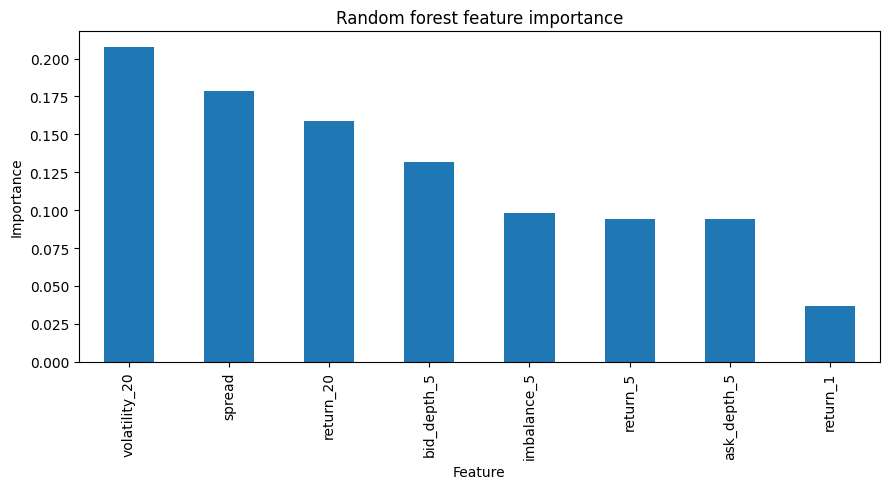

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

rf_importance = pd.Series(
    random_forest.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

display(rf_importance)

plt.figure(figsize=(9, 5))
rf_importance.plot(kind="bar")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random forest feature importance")
plt.tight_layout()
plt.show()

,0
volatility_20,0.158780
spread,0.156054
return_20,0.130681
bid_depth_5,0.129385
ask_depth_5,0.115442
imbalance_5,0.110899
return_5,0.106338
return_1,0.092421


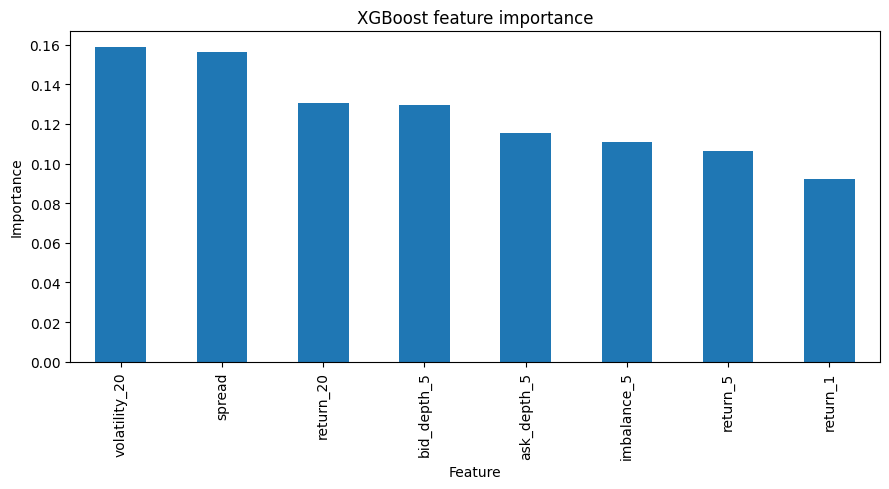

In [ ]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

display(xgb_importance)

plt.figure(figsize=(9, 5))
xgb_importance.plot(kind="bar")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("XGBoost feature importance")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Convert actual labels -1, 0, 1 into one-hot format.
y_validation_binary = label_binarize(
    y_validation,
    classes=[-1, 0, 1]
)

# Predicted probabilities
logistic_probabilities = logistic_model.predict_proba(
    X_validation
)

rf_probabilities = random_forest.predict_proba(
    X_validation
)

xgb_probabilities = xgb_model.predict_proba(
    X_validation
)

print(
    "Logistic macro AUC:",
    roc_auc_score(
        y_validation_binary,
        logistic_probabilities,
        multi_class="ovr",
        average="macro",
    )
)

print(
    "Random forest macro AUC:",
    roc_auc_score(
        y_validation_binary,
        rf_probabilities,
        multi_class="ovr",
        average="macro",
    )
)

print(
    "XGBoost macro AUC:",
    roc_auc_score(
        y_validation_binary,
        xgb_probabilities,
        multi_class="ovr",
        average="macro",
    )
)

Logistic macro AUC: 0.5366643626042329
Random forest macro AUC: 0.5774723227297566
XGBoost macro AUC: 0.5800800090431398


In [ ]:
# Add message information to the order-book table.
orderbook["event_type"] = messages["event_type"]
orderbook["message_size"] = messages["size"]
orderbook["direction"] = messages["direction"]

In [ ]:
# Event types 4 and 5 are executions.
orderbook["is_execution"] = (
    orderbook["event_type"].isin([4, 5])
).astype(int)

In [ ]:
# Only count volume when an execution occurs.
orderbook["executed_volume"] = (
    orderbook["message_size"]
    * orderbook["is_execution"]
)

# Signed volume:
# positive and negative values represent opposite trade directions.
orderbook["signed_executed_volume"] = (
    orderbook["executed_volume"]
    * orderbook["direction"]
)

In [ ]:
orderbook["trade_volume_20"] = (
    orderbook["executed_volume"]
    .rolling(20)
    .sum()
)

orderbook["signed_flow_20"] = (
    orderbook["signed_executed_volume"]
    .rolling(20)
    .sum()
)

orderbook["execution_count_20"] = (
    orderbook["is_execution"]
    .rolling(20)
    .sum()
)

orderbook["trade_volume_100"] = (
    orderbook["executed_volume"]
    .rolling(100)
    .sum()
)

orderbook["signed_flow_100"] = (
    orderbook["signed_executed_volume"]
    .rolling(100)
    .sum()
)

In [ ]:
orderbook["trade_imbalance_20"] = (
    orderbook["signed_flow_20"]
    / orderbook["trade_volume_20"].replace(0, np.nan)
)

orderbook["trade_imbalance_100"] = (
    orderbook["signed_flow_100"]
    / orderbook["trade_volume_100"].replace(0, np.nan)
)

In [ ]:
orderbook["bid_depth_change_1"] = (
    orderbook["bid_depth_5"].diff()
)

orderbook["ask_depth_change_1"] = (
    orderbook["ask_depth_5"].diff()
)

orderbook["imbalance_change_1"] = (
    orderbook["imbalance_5"].diff()
)

orderbook["imbalance_change_20"] = (
    orderbook["imbalance_5"].diff(20)
)

orderbook["spread_change_1"] = (
    orderbook["spread"].diff()
)

In [ ]:
improved_feature_columns = [
    "spread",
    "bid_depth_5",
    "ask_depth_5",
    "imbalance_5",
    "return_1",
    "return_5",
    "return_20",
    "volatility_20",
    "trade_volume_20",
    "signed_flow_20",
    "execution_count_20",
    "trade_imbalance_20",
    "trade_volume_100",
    "signed_flow_100",
    "trade_imbalance_100",
    "bid_depth_change_1",
    "ask_depth_change_1",
    "imbalance_change_1",
    "imbalance_change_20",
    "spread_change_1",
]

improved_model_data = orderbook[
    improved_feature_columns + ["target"]
].dropna()

print(improved_model_data.shape)
print(improved_model_data["target"].value_counts())
display(improved_model_data.head())

(225157, 21)
target
 0    95257
-1    66547
 1    63353
Name: count, dtype: int64


,spread,bid_depth_5,ask_depth_5,imbalance_5,return_1,return_5,return_20,volatility_20,trade_volume_20,signed_flow_20,...,trade_imbalance_20,trade_volume_100,signed_flow_100,trade_imbalance_100,bid_depth_change_1,ask_depth_change_1,imbalance_change_1,imbalance_change_20,spread_change_1,target
99,0.16,107,959,-0.799250,0.000000,0.000009,-0.000034,0.000012,48.0,-46.0,...,-0.958333,1038.0,-714.0,-0.687861,0.0,0.0,0.000000,0.058165,0.00,-1
100,0.16,107,959,-0.799250,0.000000,0.000009,-0.000034,0.000012,48.0,-46.0,...,-0.958333,1038.0,-714.0,-0.687861,0.0,0.0,0.000000,0.058165,0.00,0
101,0.13,187,959,-0.673647,0.000026,0.000026,-0.000009,0.000013,48.0,-46.0,...,-0.958333,1038.0,-714.0,-0.687861,80.0,0.0,0.125602,0.183767,-0.03,-1
102,0.13,187,959,-0.673647,0.000000,0.000026,-0.000009,0.000013,48.0,-46.0,...,-0.958333,1038.0,-714.0,-0.687861,0.0,0.0,0.000000,0.183767,0.00,-1
103,0.13,187,959,-0.673647,0.000000,0.000026,-0.000009,0.000013,48.0,-46.0,...,-0.958333,1038.0,-714.0,-0.687861,0.0,0.0,0.000000,0.168790,0.00,-1


In [ ]:
# New chronological split for the improved feature set.
train_end_improved = int(len(improved_model_data) * 0.60)
validation_end_improved = int(len(improved_model_data) * 0.80)

improved_train = improved_model_data.iloc[:train_end_improved]
improved_validation = improved_model_data.iloc[
    train_end_improved:validation_end_improved
]
improved_test = improved_model_data.iloc[validation_end_improved:]

X_train_improved = improved_train[improved_feature_columns]
y_train_improved = improved_train["target"]

X_validation_improved = improved_validation[
    improved_feature_columns
]
y_validation_improved = improved_validation["target"]

X_test_improved = improved_test[improved_feature_columns]
y_test_improved = improved_test["target"]

print("Training rows:", len(improved_train))
print("Validation rows:", len(improved_validation))
print("Test rows:", len(improved_test))

Training rows: 135094
Validation rows: 45031
Test rows: 45032


In [ ]:
improved_random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

improved_random_forest.fit(
    X_train_improved,
    y_train_improved,
)

improved_rf_predictions = improved_random_forest.predict(
    X_validation_improved
)

improved_rf_probabilities = improved_random_forest.predict_proba(
    X_validation_improved
)

print(classification_report(
    y_validation_improved,
    improved_rf_predictions,
    zero_division=0,
))

print(
    "Improved RF accuracy:",
    accuracy_score(
        y_validation_improved,
        improved_rf_predictions,
    ),
)

print(
    "Improved RF balanced accuracy:",
    balanced_accuracy_score(
        y_validation_improved,
        improved_rf_predictions,
    ),
)

              precision    recall  f1-score   support

          -1       0.40      0.67      0.50     12994
           0       0.55      0.10      0.17     20379
           1       0.38      0.65      0.48     11658

    accuracy                           0.41     45031
   macro avg       0.44      0.47      0.39     45031
weighted avg       0.46      0.41      0.35     45031

Improved RF accuracy: 0.40705291910017544
Improved RF balanced accuracy: 0.47392915366317995


In [ ]:
y_validation_improved_binary = label_binarize(
    y_validation_improved,
    classes=[-1, 0, 1],
)

print(
    "Improved RF macro AUC:",
    roc_auc_score(
        y_validation_improved_binary,
        improved_rf_probabilities,
        multi_class="ovr",
        average="macro",
    ),
)

Improved RF macro AUC: 0.6470948597110987


In [ ]:
y_train_improved_encoded = label_encoder.fit_transform(
    y_train_improved
)

improved_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)

improved_xgb.fit(
    X_train_improved,
    y_train_improved_encoded,
)

improved_xgb_predictions_encoded = improved_xgb.predict(
    X_validation_improved
)

improved_xgb_predictions = label_encoder.inverse_transform(
    improved_xgb_predictions_encoded
)

improved_xgb_probabilities = improved_xgb.predict_proba(
    X_validation_improved
)

print(classification_report(
    y_validation_improved,
    improved_xgb_predictions,
    zero_division=0,
))

print(
    "Improved XGBoost accuracy:",
    accuracy_score(
        y_validation_improved,
        improved_xgb_predictions,
    ),
)

print(
    "Improved XGBoost balanced accuracy:",
    balanced_accuracy_score(
        y_validation_improved,
        improved_xgb_predictions,
    ),
)

print(
    "Improved XGBoost macro AUC:",
    roc_auc_score(
        y_validation_improved_binary,
        improved_xgb_probabilities,
        multi_class="ovr",
        average="macro",
    ),
)

              precision    recall  f1-score   support

          -1       0.43      0.49      0.46     12994
           0       0.51      0.41      0.45     20379
           1       0.40      0.48      0.44     11658

    accuracy                           0.45     45031
   macro avg       0.45      0.46      0.45     45031
weighted avg       0.46      0.45      0.45     45031

Improved XGBoost accuracy: 0.45095600808332037
Improved XGBoost balanced accuracy: 0.46004428992465246
Improved XGBoost macro AUC: 0.6426783668768831


In [ ]:
# Encode the untouched test labels.
y_test_improved_encoded = label_encoder.transform(
    y_test_improved
)

# Generate test predictions and probabilities.
test_predictions_encoded = improved_xgb.predict(
    X_test_improved
)

test_predictions = label_encoder.inverse_transform(
    test_predictions_encoded
)

test_probabilities = improved_xgb.predict_proba(
    X_test_improved
)

# Prepare labels for multiclass AUC.
y_test_improved_binary = label_binarize(
    y_test_improved,
    classes=[-1, 0, 1],
)

print(classification_report(
    y_test_improved,
    test_predictions,
    zero_division=0,
))

print(
    "Test accuracy:",
    accuracy_score(
        y_test_improved,
        test_predictions,
    ),
)

print(
    "Test balanced accuracy:",
    balanced_accuracy_score(
        y_test_improved,
        test_predictions,
    ),
)

print(
    "Test macro AUC:",
    roc_auc_score(
        y_test_improved_binary,
        test_probabilities,
        multi_class="ovr",
        average="macro",
    ),
)

              precision    recall  f1-score   support

          -1       0.37      0.58      0.45     11750
           0       0.53      0.25      0.34     22922
           1       0.37      0.57      0.45     10360

    accuracy                           0.41     45032
   macro avg       0.42      0.46      0.41     45032
weighted avg       0.45      0.41      0.39     45032

Test accuracy: 0.40711049920056847
Test balanced accuracy: 0.4646934137782546
Test macro AUC: 0.6417071774199549


In [ ]:
results = pd.DataFrame({
    "model": [
        "Baseline",
        "Logistic",
        "Random Forest",
        "Improved Random Forest",
        "Improved XGBoost",
    ],
    "balanced_accuracy": [
        0.3333,
        0.3641,
        0.4025,
        0.4739,
        0.4647,
    ],
    "macro_auc": [
        0.5000,
        0.5367,
        0.5775,
        0.6471,
        0.6417,
    ],
})

display(results)

,model,balanced_accuracy,macro_auc
0,Baseline,0.3333,0.5000
1,Logistic,0.3641,0.5367
2,Random Forest,0.4025,0.5775
3,Improved Random Forest,0.4739,0.6471
4,Improved XGBoost,0.4647,0.6417
